![logo](./assets/seattle.png).

# Analyse Exploratoire

## Introduction
On rappelle que la mission dans son ensemble a pour but de **tenter de prédire les émissions de C02** et la **consommation totale d'énergie** de bâtiments **non destinés à l'habitation**

## Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from lib.non_res_types import non_res_types

## Analyse

### Aperçu et pré-filtrage du jeu de données

Ci-dessous un aperçu du jeu de données. On souhaite : 

* Savoir comment se présente le jeu de données de manière générale
* Connaître les différentes colonnes du jeu de données
* Analyser le type de bâtiment afin de pré-filtrer les bâtiments **non destinés à l'habitation**
  
### Aperçu général

In [2]:


building_consumption = pd.read_csv("./assets/building.csv")

print(f"Nombre total de lignes : {len(building_consumption)}")

# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

Nombre total de lignes : 3376


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [3]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
# building_consumption.info() # décommenter cette ligne pour ré-afficher la liste des colonnes et les valeurs manquantes


In [4]:
# on regarde les types de bâtiments
building_type_counts = building_consumption['BuildingType'].value_counts()
print(building_type_counts)

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64


### Liste des colonnes

Ci-dessous, nous allons lister toutes les colonnes et faire nos premières observations sur ces dernières.

* `OSEBuildingID` : id unique pour le bâtiment
  * très utile pour identifier le bâtiment, mais certainement à retirer de l'entrainement pour ne pas induire le modèle en erreur
* `DataYear` : année de collecte de la donnée sur l'individu (bâtiment)
  * toujours la même valeur : 2016
* `BuildingType` : type de bâtiment
  * principal discriminant pour notre analyse qui ne concerne que les **bâtiments non résidentiels**
* `PrimaryPropertyType` : usage (type) principal du bâtiment
* `PropertyName` : Nom principal
  * certainement à retirer de l'entrainement du modèle
* `Address` : adresse, peut donner une indication sur la localisation fine (nom de rue)
  * certainement à retirer de l'entrainement du modèle pour éviter de lier des résultats à partir de noms arbitraires de rues
* `City` / `State`: Seattle, WA :)
* `ZipCode` : code postal, peut donner une indication de zone
* `TaxParcelIdentificationNumber` : champ administratif mais pourrait donner une indication de zone
* `CouncilDistrictCode` : idem ici.
* `Neighborhood` : Quartier, donne une indication de zone claire
  * peut être intéressant à garder dans l'analyse et la construction du modèle : la consommation d'énergie pourrait être corrélée aux quartiers car dépendante des infrastructures liées au quartier
* `Latitude` / `Longitude`: indication de localisation la plus fine peut être une des seules à garder avec le quartier ?
* `YearBuilt` : Année de construction
  * cette information me parait très pertinente pour l'analyse, car selon l'année les matériaux utilisés et les normes de construction diffèrent et influent sur la consommation en énergie
* `NumberOfBuildings` : nombre de constructions (bâtiments)
  * cette information me parait importante pour la consommation en énergie : plus de bâtiments implique plus de surface en contact avec l'air (ponts thermiques)
* `NumberOfFloors`: nombre d'étages : idem, mais en hauteur
* `PropertyGFATotal` : surface totale
  * champ très important, unité à éclaircir
* `PropertyGFAParking` : surface en parking
  * champ pertinent, unité à éclaircir
* `PropertyGFABuilding(s)` : surface en bâtiment (hors parking)
  * idem
* `ListOfAllPropertyUseTypes` : liste de tous les types d'usage du bâtiment
  * champ pertinent à rapprocher des champs suivants car la diversité des usages peut être un facteur important
* `LargestPropertyUseType` : principal type d'usage
* `LargestPropertyUseTypeGFA`: surface pour le principal type d'usage
* `SecondLargestPropertyUseType` : second type d'usage
* `SecondLargestPropertyUseTypeGFA` : surface pour le second type d'usage
* `ThirdLargestPropertyUseType` : troisième type d'usage
* `ThirdLargestPropertyUseTypeGFA`: surface pour le troisième type d'usage
* `YearsENERGYSTARCertified` : année d'obtention la certification ENERGYSTAR
  * peut être pertinente, à utiliser avec les champs suivants
  * beaucoup de valeurs manquantes, je pense qu'il faut normaliser ce champ pour le garder toutefois
* `ENERGYSTARScore` score ENERGYSTAR
  * champ important, score directement lié à la consommation d'énergie et émissions de C02
* `SiteEUI(kBtu/sf)` : Consommation d’énergie du site par surface, mesurée en kBtu par pied carré
  * champ pertinent, ainsi que tous les autres qui suivent concernant la consommation d'énergie
  * attention certains de ces champs peuvent être des cibles potentielles (à prédire), donc à ne pas utiliser comme features si c'est le cas
* `SiteEUIWN(kBtu/sf)` : Même chose que SiteEUI, mais ajustée pour les variations climatiques
* `SourceEUI(kBtu/sf)` : Consommation d’énergie totale (incluant pertes de production et transport) par surface, en kBtu par pied carré
* `SourceEUIWN(kBtu/sf)` : SourceEUI ajustée pour les variations climatiques
* `SiteEnergyUse(kBtu)` : Quantité totale d’énergie consommée sur le site, en kBtu
* `SiteEnergyUseWN(kBtu)` : SiteEnergyUse ajustée pour les variations climatiques
* `SteamUse(kBtu)` : Quantité totale de vapeur utilisée par le bâtiment, en kBtu
* `Electricity(kWh)`: Consommation d'électricité en kw/h
* `Electricity(kBtu)`: Consommation d'électricité en kBtu
* `NaturalGas(therms)`: Consommation de gaz en therm
* `NaturalGas(kBtu)`: Consommation de gaz en kBtu
* `DefaultData`: Champ booléen qui semble indiquer si la donnée a été remplacée par une donnée par défaut (estimée ou valeur arbitraire, mais pas réelle)
  * attention à ce champ dans la création de modèle, il peut être pertinent de garder les individus à VRAI mais cela pourrait aussi fausser les prédictions
* `Comments`: commentaire sur l'individu, aucune donnée
* `ComplianceStatus`: statut de conformité des données de l'individu
  * champ très important qui va nous permettre d'améliorer notre analyse
  * plusieurs valeurs dont l'identification des données par défaut, de manque de données mais surtout si l'individu est totalement conforme ("Compliant")
* `Outlier`: individu avec des données "abbérantes", éloignées des autres individus
  * champ très intéressant, on pourrait entrainer plusieurs modèles avec et sans les outliers et comparer les performances
  * il faut analyser les données et tenter de les filtrer selon s'ils semblent représenter une situation réelle ou non
* `TotalGHGEmissions`: Total des émissions de gaz à effet de serre
  * champ très important pour prédire les émissions
  * attention à ne pas utiliser comme feature si c'est la variable à prédire
* `GHGEmissionsIntensity`: Intensité des émissions de gaz à effet de serre
  * idem

### Bilan

On observe les différentes colonnes, on peut dores et déjà se rendre compte : 

* Certaines colonnes ont une grande quantité de valeurs non définies (total - x non-null conséquent), notamment :
  * `SecondLargestPropertyUseType`
  * `ThirdLargestPropertyUseType`
  * `ENERGYSTARScore`
  * `YearsENERGYSTARCertified`
  * etc.
* Une colonne spécifique semble identifier les outliers : `Outlier`
* La colonne discriminante pour le type de bâtiment est `BuildingType`
  * elle va nous permettre de retirer dès le départ les bâtiments non résidentiels du jeu de données
* Certaines colonnes inutiles pour l'analyse alourdissent notre jeu de données
  * on les supprimera, mais on gardera `OSEBuildingID` pour permettre d'identifier les individus (bâtiments) et retrouver ces informations ultérieurement si nécessaire

In [5]:
# Constitution du nouveau jeu de données : on va garder uniquement les types de bâtiments non résidentiels
# types considérés comme non résidentiels (cf. non_res_types.py), rendu générique pour réutilisation : "NonResidential", "SPS-District K-12", "Nonresidential COS", "Campus", "Nonresidential WA"

df = building_consumption[building_consumption['BuildingType'].isin(non_res_types)]

# On supprime les colonnes que l'on considère inutiles pour notre analyse afin d'alléger le dataframe
df = df.drop(['DataYear', 'Address', 'City', 'State', 'Comments'], axis=1)

print(f"Nombre total de lignes après premier filtrage : {len(df)}")

Nombre total de lignes après premier filtrage : 1668


## Nettoyage du jeu de données

Nous avons déjà considérablement réduit notre jeu de données en retirant les bâtiments non concernés par l'analyse et en supprimant quelques colonnes inutiles.
Nous allons désormais nous **focaliser sur les valeurs des données afin de s'assurer qu'elles seront exploitables dans notre analyse**

### données non conformes ou déduites

On remarque dans le jeu de données la variable `ComplianceStatus`. Certaines données ne sont pas conformes, on va les écarter dès le départ. On fait de même avec les données déduites par défaut


In [6]:
#error_count = (df['ComplianceStatus'] == "Error - Correct Default Data").sum() # ==> 88 rows
#non_compliant_count = (df['ComplianceStatus'] == "Non-Compliant").sum() # ==> 18 rows

# Total 106 non-compliant rows, we remove it definitively
df = df[~df['ComplianceStatus'].isin(["Error - Correct Default Data", "Non-Compliant"])]

# On constate qu'il n'y a plus d'outliers, la totalité était marquée en non conforme, on supprime alors la colonne qui n'est plus utile
# Si les outliers n'étaient pas marqués non conformes on les aurait gardé et recherché les plus aberrants pour les traiter
df = df.drop(['Outlier'], axis=1)

# Après plusieurs itérations sur l'analyse, on se rend compte que malgré le filtrage par `BuildingType` on a des données incohérentes qui représentent encore des bâtiments résidentiels (23 lignes), on les retire : 
df = df[~df['PrimaryPropertyType'].isin(['Low-Rise Multifamily', 'Residence Hall'])] 
df = df[~df['SecondLargestPropertyUseType'].isin(['Multifamily Housing'])] 

print(f"Nombre total de lignes après suppression des données non conformes ou déduites : {len(df)}")

Nombre total de lignes après suppression des données non conformes ou déduites : 1527


### données manquantes

Ci-dessous un aperçu du nombre de données non renseignées par colonne : 

In [7]:
print(df.isnull().sum())

OSEBuildingID                         0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
ZipCode                              13
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     0
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             0
LargestPropertyUseType                4
LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseType        704
SecondLargestPropertyUseTypeGFA     704
ThirdLargestPropertyUseType        1192
ThirdLargestPropertyUseTypeGFA     1192
YearsENERGYSTARCertified           1430
ENERGYSTARScore                     554


Commençons par traiter les colonnes pour lesquelles il y a beaucoup de données manquantes. Traitons-les par ensembles cohérents afin d'effectuer un traitement unifié.


In [8]:
building_usage = ['SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']

# Vérification de cohérence : si surface = 0, le type d'usage doit être renseigné (pas de valeur manquante)
mask = (df['SecondLargestPropertyUseTypeGFA'] == 0) & df['SecondLargestPropertyUseType'].isnull()
mask2 = (df['ThirdLargestPropertyUseTypeGFA'] == 0) & df['ThirdLargestPropertyUseType'].isnull()

# On remplace les valeurs pour la compréhension de notre modèle
if (not mask.sum() and not mask2.sum()):
   df['SecondLargestPropertyUseTypeGFA'] = df['SecondLargestPropertyUseTypeGFA'].fillna(0)
   df['ThirdLargestPropertyUseTypeGFA'] = df['ThirdLargestPropertyUseTypeGFA'].fillna(0)
   df['SecondLargestPropertyUseType'] = df['SecondLargestPropertyUseType'].fillna('No Usage')
   df['ThirdLargestPropertyUseType'] = df['ThirdLargestPropertyUseType'].fillna('No Usage')
else: 
    print(f("Erreur: problème de cohérence entre les champs second et 3e usage et leur surface respective"))

# Correction pour signaler une valeur manquante au modèle
# note : pour LargestPropertyUseType et LargestPropertyUseTypeGFA, il n'y a que 4 valeurs manquantes, attention on pourra revenir ici pour les retirer complètement selon les performances du modèle
cols = ['ENERGYSTARScore', 'ZipCode', 'YearsENERGYSTARCertified', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA']
df[cols] = df[cols].fillna(-1)

# Il n'y a que 2 valeurs manquantes ici, qui représentent un seul individu, on préfère le retirer du jeu de données
df = df.dropna(subset=['SiteEUIWN(kBtu/sf)', 'SiteEnergyUseWN(kBtu)'])

# Décommenter pour obtenir un nouvel aperçu des valeurs manquantes après traitement des données    
# print(df.isnull().sum()) ==> plus aucune donnée manquante

print(f"Nombre total de lignes après suppression d'individus avec des données manquantes: {len(df)}")

Nombre total de lignes après suppression d'individus avec des données manquantes: 1526


### doublons

Il n'y a aucun doublon détecté :

In [9]:
df.duplicated().sum() # résultat ==> 0
# df.loc[df['OSEBuildingID'].duplicated(keep=False),:] # autre méthode basée sur l'id ==> résultat 0 rows

np.int64(0)

## Analyse complémentaire des variables
### Usage des bâtiments
L'usage des bâtiments, associé à la surface utilisée sont des facteurs déterminants pour prédire la consommation énergétique.
Dans cette analyse on va tenter de mieux comprendre les usages possibles et les tendances qui en découlent.

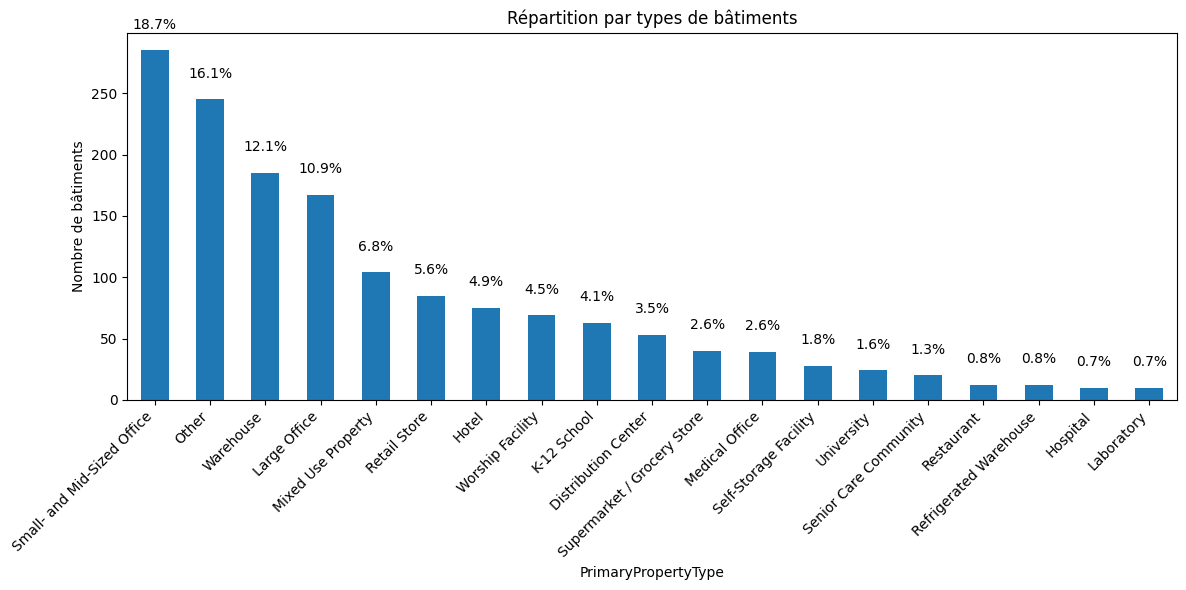

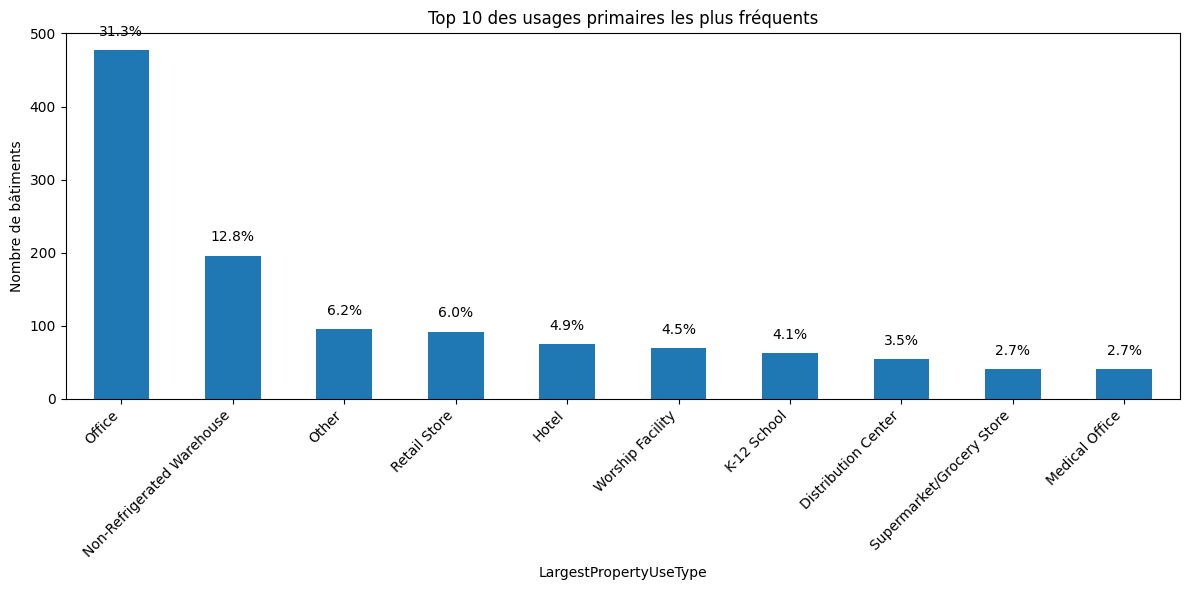

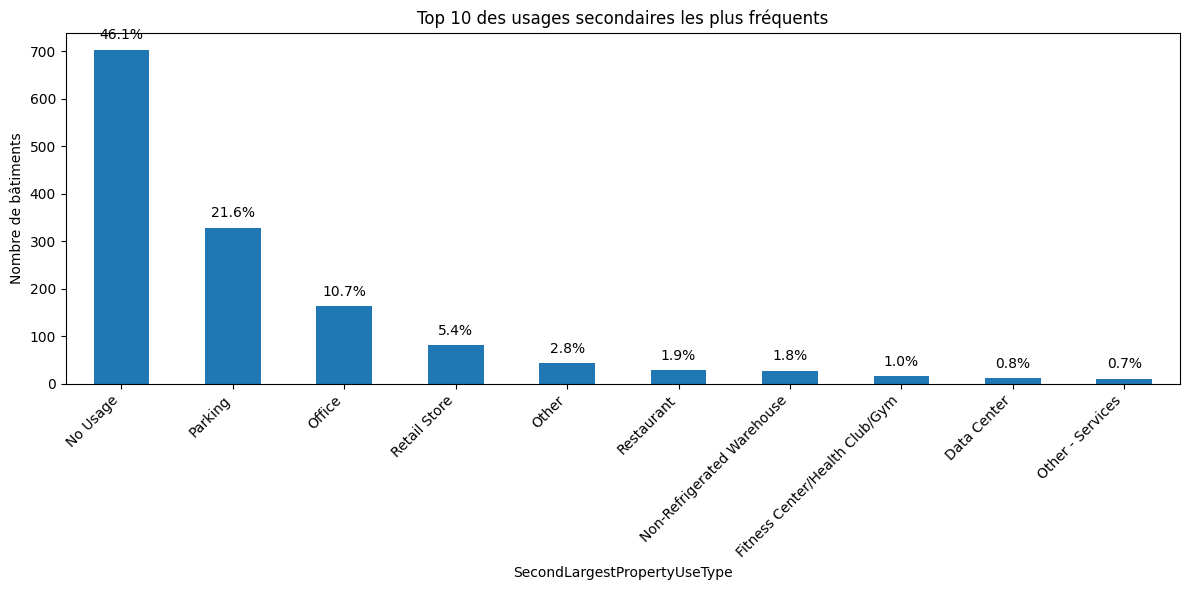

In [14]:
# Histogramme pour PrimaryPropertyType
plt.figure(figsize=(12, 6))
counts = df['PrimaryPropertyType'].value_counts()
ax = counts.plot(kind='bar')
total = counts.sum()
for i, v in enumerate(counts):
    ax.text(i, v + total*0.01, f'{v/total*100:.1f}%', ha='center', va='bottom')
plt.title('Répartition par types de bâtiments')
plt.xlabel('PrimaryPropertyType')
plt.ylabel('Nombre de bâtiments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Histogramme pour LargestPropertyUseType
plt.figure(figsize=(12, 6))
counts = df['LargestPropertyUseType'].value_counts().head(10)
ax = counts.plot(kind='bar')
total = df['LargestPropertyUseType'].value_counts().sum()
for i, v in enumerate(counts):
    ax.text(i, v + total*0.01, f'{v/total*100:.1f}%', ha='center', va='bottom')
plt.title('Top 10 des usages primaires les plus fréquents')
plt.xlabel('LargestPropertyUseType')
plt.ylabel('Nombre de bâtiments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Histogramme pour SecondLargestPropertyUseType
plt.figure(figsize=(12, 6))
counts = df['SecondLargestPropertyUseType'].value_counts().head(10)
ax = counts.plot(kind='bar')
total = df['SecondLargestPropertyUseType'].value_counts().sum()
for i, v in enumerate(counts):
    ax.text(i, v + total*0.01, f'{v/total*100:.1f}%', ha='center', va='bottom')
plt.title('Top 10 des usages secondaires les plus fréquents')
plt.xlabel('SecondLargestPropertyUseType')
plt.ylabel('Nombre de bâtiments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
